# Práctica 1 MASDFR — Equipo 9
**Asignatura:** Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro  

## Integrantes del equipo

* Ortiz Meza Ricardo - 320170472 (Dueño del fork)
* Barajas Avila Jorge Antonio
* Díaz Santivañez Carlos Emilio - 421091137
* Marroquín Ortega David 320284308

---


* **Ramo Seleccionado:** Seguro de Automóviles.
* **¿Por qué nos interesó este ramo?:**  
  Elegimos el ramo de Automóviles debido a su alta relevancia económica, social y técnica dentro del sector asegurador. Se trata de uno de los ramos con mayor volumen de primas y dinamismo en el mercado mexicano, además de contar con un amplio respaldo de información estadística (frecuencias de siniestro, severidades, bases de datos públicas y reportes de la AMIS/CNSF), lo cual permite realizar análisis actuariales rigurosos y realistas.
Asimismo, el ramo automotriz presenta retos técnicos sumamente interesantes: la tarificación multivariada por perfiles de riesgo (modelo del vehículo, zona geográfica, uso de la unidad). Esto lo convierte en el ramo ideal para aplicar los fundamentos de suscripción, diseño de producto y modelación de pérdidas.

* **Coberturas a trabajar en el producto:**  
Para nuestro producto hemos seleccionado las tres coberturas fundamentales que conforman la base de una póliza tradicional de cobertura amplia, permitiéndonos modelar los diferentes componentes de riesgo (alta frecuencia y baja severidad vs. baja frecuencia y alta severidad):
	* Responsabilidad Civil (Daños a Terceros)
	* Daños Materiales al Vehículo
	* Robo Total

---

# Librerías a usar

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import statsmodels.api as sm
np.random.seed(0); plt.rcParams["figure.figsize"] = (8, 3.6)
from scipy.stats import skew, kurtosis


# Comprobación del entorno de ejecución (directorio)

In [2]:
import os

print("Directorio actual:", os.getcwd())

print("Contenido del directorio:", os.listdir())

Directorio actual: c:\Users\Emilio Diaz\Documents\MASDFR_20271\entregas\equipo_09\inputs
Contenido del directorio: ['cartera.parquet', 'Practica 1 - Equipo 9.html', 'Practica 1 - Equipo 9.ipynb']


# 0. Formato general de las gráficas

In [3]:
# Define el tamaño predeterminado de las gráficas, ancho de 9 pulgadas y un alto de 4.2 pulgadas
plt.rcParams["figure.figsize"] = (9, 4.2)

# Formato de las líneas de la cuadrícula (grid) en el fondo de todas las gráficas.
## Activa las grid , para facilitar la detección de los valores en los ejes.
plt.rcParams["axes.grid"] = True
## Color sutil de las grid.
plt.rcParams["grid.alpha"] = 0.3

# Selección de Variables y Criterio Actuarial

Para esta primera práctica se eligieron algunas variables de la cartera. Por ahora no se consideran datos como la edad del conductor, la zona o el tipo de vehículo, ya que se utilizarán en la Práctica 2.

**exposicion:** Indica el tiempo que cada póliza estuvo cubierta. Se utiliza para calcular correctamente la frecuencia de siniestros.

**num_siniestros**: Indica cuántos siniestros tuvo cada póliza durante el periodo.

**monto_total_siniestros / monto_promedio_siniestro**: Indican cuánto dinero representaron los siniestros.

**deducible, suma_asegurada y coaseguro**: Son las condiciones de la póliza que ayudan a determinar cuánto dinero termina pagando la aseguradora.


* **¿Por qué seleccionamos estas variables?:**  

Elegimos estas variables ya que son necesarias calcular la frecuencia y la severidad de los siniestros. Además, la exposición y el número de siniestros sirven para saber conocer la frecuencia de los siniestros, sin esta exposición no se podría comparar de manera correcta las pólizas que estuvieron activas todo el año contra las pólizas que solo estuvieron unos meses. Por otro lado, el monto total de siniestros y el monto promedio por siniestro muestran qué tan caro sale cada siniestro.

El deducible, la suma asegurada y el coaseguro fueron seleccionados ya que son las condiciones del contrato, básicamente nos dicen cuánto del siniestro paga realmente la aseguradora y cuánto le queda al asegurado.

# 1. Importación de datos y exploración de las variables de interés

## Importación de datos

In [4]:
# Guardamos la ruta del archivo parquet "cartera.parquet" con los datos de la cartera de siniestro del equipo 9.
ruta_cartera = Path("../inputs/cartera.parquet")

# Si no existe la ruta, intentamos volver a buscarla manualmente.
if not ruta_cartera.exists():
    dir_actual = Path.cwd()
    archivos = list(dir_actual.rglob("cartera.parquet")) or list(dir_actual.parents[2].rglob("cartera.parquet"))
    if archivos:
        ruta_cartera = archivos[0]
    else:
        raise FileNotFoundError(f"No se encontró el archivo cartera.parquet en {ruta_cartera.resolve()}")

# Guardamos la información de la cartera en un dataframe para poder manipular los datos.
df = pd.read_parquet(ruta_cartera)

print(f"Cartera cargada exitosamente de la ruta: {ruta_cartera})")
print("- Total de Pólizas (Filas): ", len(df))
print("- Total de Variables/Características de la Póliza (Columnas): ", len(df.columns))
# Imprimimos cada columna en una línea
print("\nLista de columnas línea por línea:")
for columna in df.columns:
    print("-", columna)

print()
print("-"*50)

# 2. Subconjunto explícito de variables que elegimos
cols_interes = [
    "exposicion", "num_siniestros", "monto_total_siniestros",
    "monto_promedio_siniestro", "deducible", "suma_asegurada", "coaseguro"
]

print(f"Subconjunto de variables a trabajar en la Práctica 1 ({len(cols_interes)} variables):")
print("*  Frecuencia : exposicion, num_siniestros,")
print("*  Severidad  : monto_total_siniestros, monto_promedio_siniestro (ground-up)")
print("*  Póliza     : deducible, suma_asegurada, coaseguro (para transformar)")
print("\nLos factores (edad_conductor, tipo_vehiculo, zona, ...) NO considerarán para este modelo: son para el GLM (P2).")

df_modelo = df[cols_interes].copy()

Cartera cargada exitosamente de la ruta: ..\inputs\cartera.parquet)
- Total de Pólizas (Filas):  30000
- Total de Variables/Características de la Póliza (Columnas):  14

Lista de columnas línea por línea:
- id_poliza
- exposicion
- edad_conductor
- sexo
- antiguedad_vehiculo
- tipo_vehiculo
- uso
- zona
- suma_asegurada
- deducible
- coaseguro
- num_siniestros
- monto_total_siniestros
- monto_promedio_siniestro

--------------------------------------------------
Subconjunto de variables a trabajar en la Práctica 1 (7 variables):
*  Frecuencia : exposicion, num_siniestros,
*  Severidad  : monto_total_siniestros, monto_promedio_siniestro (ground-up)
*  Póliza     : deducible, suma_asegurada, coaseguro (para transformar)

Los factores (edad_conductor, tipo_vehiculo, zona, ...) NO considerarán para este modelo: son para el GLM (P2).


In [5]:
!pip install tabulate
import tabulate
print(df.head().to_markdown())

|    | id_poliza   |   exposicion |   edad_conductor | sexo   |   antiguedad_vehiculo | tipo_vehiculo   | uso        | zona      |   suma_asegurada |   deducible |   coaseguro |   num_siniestros |   monto_total_siniestros |   monto_promedio_siniestro |
|---:|:------------|-------------:|-----------------:|:-------|----------------------:|:----------------|:-----------|:----------|-----------------:|------------:|------------:|-----------------:|-------------------------:|---------------------------:|
|  0 | P000001     |        0.853 |               70 | F      |                     8 | suv             | particular | occidente |           585887 |       29294 |           0 |                0 |                        0 |                        nan |
|  1 | P000002     |        0.856 |               49 | F      |                    12 | compacto        | comercial  | occidente |           487765 |       24388 |           0 |                0 |                        0 |                  


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\Emilio Diaz\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


## Exploración de las variables de interés

	---- EXPLORACIÓN A NIVEL PÓLIZA ----

% de pólizas con al menos un siniestro : 23.2%
Exposición total                       : 24,032 años-póliza
Severidad (monto_promedio) → media: 50,702
Severidad (monto_promedio) → mediana: 33,058


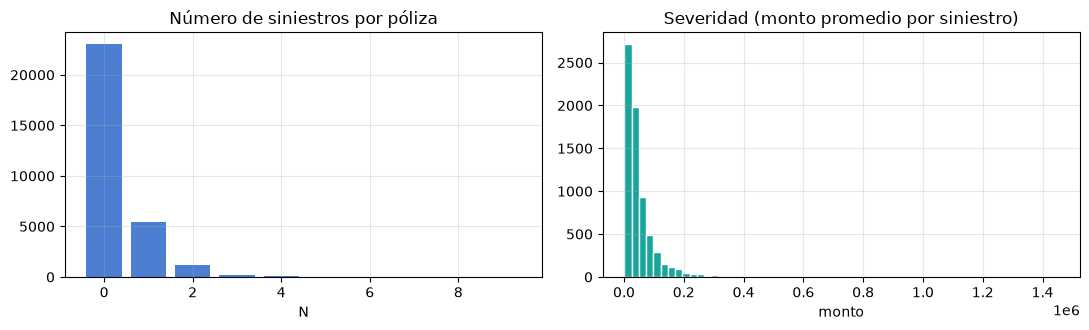

In [6]:
print("\t---- EXPLORACIÓN A NIVEL PÓLIZA ----")
# Pólizas con al menos un siniestro
min_1_siniestro = df[df.num_siniestros > 0]

# Proporción de pólizas que tuvieron al menos un siniestro
print(f"\n% de pólizas con al menos un siniestro : {(df.num_siniestros>0).mean():.1%}")
print(f"Exposición total                       : {df.exposicion.sum():,.0f} años-póliza")

# Calcula la media y mediana directamente sobre los montos promedio por póliza. 
# Cada póliza cuenta exactamente una vez, sin importar si tuvo 1 o varios siniestros.
print(f"Severidad (monto_promedio) → media: {min_1_siniestro.monto_promedio_siniestro.mean():,.0f}")
print(f"Severidad (monto_promedio) → mediana: {min_1_siniestro.monto_promedio_siniestro.median():,.0f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(*np.unique(df.num_siniestros, return_counts=True), color="#4C7FD1")
ax[0].set_title("Número de siniestros por póliza"); ax[0].set_xlabel("N")
ax[1].hist(min_1_siniestro.monto_promedio_siniestro, bins=60, color="#17A69B", edgecolor="white")
ax[1].set_title("Severidad (monto promedio por siniestro)"); ax[1].set_xlabel("monto")
plt.tight_layout(); plt.show()

**Explicación de las gráficas:**

Gráfica: Número de siniestros por póliza

En este caso, cada barra indica cuántas pólizas tuvieron siniestros en el año. Observamos que la barra en 0 es es la más grande ya que la mayoría de la gente no choca ni reporta nada. Asi, conforme recorremos el eje X, las barras se disminuyen su tamaño, ya que casi ningun caso presenta 4 o más siniestros. 

Gráfica: Severidad

Visualizamos el costo de los siniestros presentados, se presentan muchos más casos por una cantidad relativamente pequeña que los siniestros grandes que se extienden sobre el eje X.

In [14]:
print("\t---- EXPLORACIÓN GROUND-UP (A NIVEL SINIESTRO) ----")

# Descriptivos actuariales de Frecuencia y Exposición 
total_exp = df_modelo["exposicion"].sum()
total_sins = df_modelo["num_siniestros"].sum()
tasa_frecuencia = total_sins / total_exp

print("\n * FRECUENCIA Y EXPOSICIÓN GLOBAL")
print(f"• Exposición total acumulada : {total_exp:,.2f} años-póliza")
print(f"• Siniestros totales         : {total_sins:,.0f} eventos")
print(f"• Tasa de Frecuencia (λ)     : {tasa_frecuencia:.4f} siniestros por año-póliza")

print("\n * DESCRIPTIVOS DE VARIABLES DE FRECUENCIA Y EXPOSICIÓN")
print(df_modelo[["num_siniestros", "exposicion"]].describe().round(4))

# Reconstrucción y Descriptivos de Severidad Ground-Up
polizas_con_sins = df_modelo[df_modelo["num_siniestros"] > 0].copy()
 
# Reconstruimos el universo real de siniestros individuales (8,856 eventos) 
# ponderando los montos (severidad) por el volumen de eventos (frecuencia) con la función "np.repeat()"
sev_gu = np.repeat(
    polizas_con_sins["monto_promedio_siniestro"].values,
    polizas_con_sins["num_siniestros"].astype(int).values
)

print(f"\n * SEVERIDAD GROUND-UP ({len(sev_gu):,} SINIESTROS RECONSTRUIDOS)")
desc_sev = pd.Series(sev_gu).describe()
for stat, val in desc_sev.items():
    print(f"{stat:<8} {val:12.2f}")

print()
print(f"Sesgo (Skewness) : {skew(sev_gu):.4f}")
print(f"Curtosis         : {kurtosis(sev_gu):.4f}")

	---- EXPLORACIÓN GROUND-UP (A NIVEL SINIESTRO) ----

 * FRECUENCIA Y EXPOSICIÓN GLOBAL
• Exposición total acumulada : 24,031.87 años-póliza
• Siniestros totales         : 8,856 eventos
• Tasa de Frecuencia (λ)     : 0.3685 siniestros por año-póliza

 * DESCRIPTIVOS DE VARIABLES DE FRECUENCIA Y EXPOSICIÓN
       num_siniestros  exposicion
count      30000.0000  30000.0000
mean           0.2952      0.8011
std            0.6119      0.1199
min            0.0000      0.2040
25%            0.0000      0.7290
50%            0.0000      0.8210
75%            0.0000      0.8940
max            9.0000      0.9990

 * SEVERIDAD GROUND-UP (8,856 SINIESTROS RECONSTRUIDOS)
count         8856.00
mean         51046.04
std          57283.68
min           1479.92
25%          19357.33
50%          34872.57
75%          62086.29
max        1452742.67

Sesgo (Skewness) : 5.4365
Curtosis         : 68.1975


## Justificación.

- **Exposición y frecuencia general:**
  La cartera tiene un total de 30,000 pólizas, donde únicamente el 23.2% de ellas tuvo por lo menos un siniestro.
  La severidad promedio fue de $50,702 y la mediana se encuentra en $33,058

- **Exposición y frecuencia global:**

  La cartera tiene un total de 24,031.87 años-póliza expuestos y 8,856 siniestros registrados. Con estos datos se obtiene una frecuencia global de $\lambda = 0.3685$ siniestros por año-póliza.

  Se utiliza la exposición real de cada póliza porque no todas las pólizas estuvieron aseguradas durante el mismo tiempo.

- **Distribución de los montos de los siniestros:**

  - **Media y mediana:** La media es de **$51,046.04**, mientras que la mediana es de **$34,872.57**. La diferencia entre ambas indica que existen algunos siniestros con montos muy altos que aumentan el promedio.

  - **Máximo y mínimo:** El monto máximo de los siniestros fue de **$1,452,742.67** , mientras que el mínimo fue de **$1,479.92**. Esto confirma la existencia de siniestros con una siniestralidad muy alta, lo cual indica colas pesadas en el modelo.

  - **Siniestros de montos altos:** El sesgo de **5.4365** y la curtosis de **68.1975** muestran que hay varios valores extremos y una concentración importante de siniestros hacia montos altos.

  Esto indica que los montos de los siniestros no se distribuyen de manera uniforme y que hay algunos casos mucho más costosos que la mayoría. Por esto, en el **inciso b)** se probarán distribuciones como **Lognormal y Pareto**, que pueden representar mejor este tipo de comportamiento.


> En `cartera.parquet`, los siniestros están resumidos por póliza mediante `monto_promedio_siniestro`. Como no tenemos el monto de cada siniestro por separado, se repitió el monto promedio de cada póliza tantas veces como siniestros tuvo, usando `np.repeat`.
>
> De esta forma podemos trabajar con los datos disponibles y mantener el promedio general de los siniestros. Sin embargo, esto puede hacer que la variación real entre siniestros sea un poco menor.

# 2. Severidad

La severidad, denotada como **X**, representa el monto de un siniestro.

Ajustamos varias distribuciones al `monto_promedio_siniestro` (ground-up), en base al método de **AIC** y la **cola** seleccionamos la distribución que mejor se ajuste al modelo.

# NOTA: Severidad real VS Severidad ponderada

A partir de este punto vamos a utilizar la severidad ponderada, es decir, transicionamos de un análisis a nivel de póliza a un enfoque Ground-Up basado en el volumen real de eventos, con el fin de reflejar la realidad financiera de la cartera.

Esta modificación la realizamos debido a que:
- Si analizamos la severidad únicamente a nivel de póliza (tratando cada contrato como una unidad independiente), una póliza que generó cinco siniestros tiene exactamente el mismo peso estadístico que una que solo reportó uno. Esto distorsiona la realidad operativa, es decir, produce un sesgo estadístico, ya que los asegurados con alta siniestralidad concentran el verdadero riesgo financiero de la cartera.

- Al ponderar los montos de los siniestros por su frecuencia (mediante la repetición de eventos por póliza), reconstruimos el universo real de siniestros individuales (pasamos de miles de pólizas a los miles de eventos de siniestros que efectivamente ocurrieron). Esto garantiza que las métricas de tendencia central —como la media y la mediana— no subestimen ni sobreestimen el costo real de los siniestros.

- Los modelos de severidad (como Lognormal, Gamma, Weibull o Pareto) dependen de la correcta identificación de la forma de la distribución (sesgo y curtosis). Un análisis sin ponderar ignora el peso de los eventos extremos en las carteras recurrentes, lo que llevaría a un ajuste erróneo de las colas de la distribución.

- Una estimación imprecisa de la severidad debido a la falta de ponderación se traduce directamente en primas insuficientes o reservas técnicas mal calculadas. Ponderar adecuadamente permite al actuario alinear la tarifa con la exposición real al riesgo, garantizando la solvencia de la institución aseguradora.

En conclusión, ponderar los siniestros transforma una perspectiva simplificada de las pólizas en una perspectiva más precisa de la siniestralidad, permitiendo mejorar el cálculo de reservas.

## Ajuste de distribuciones de severidad mediante AIC (Criterio de Información de Akaike)

In [8]:
# Diccionario de distribuciones candidatas de Severidad Ground-Up
candidatas = {
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Weibull": stats.weibull_min,
    "Pareto": stats.pareto,
    "Exponencial": stats.expon,
    "Log-logística": stats.invgauss
}

# Función para calcular el AIC = 2k - 2 ln(L)
# k = número de parámetros estimados del modelo.
# L = máxima verosimilitud del modelo.
def calcular_aic(dist, params, datos):
    log_lik = np.sum(dist.logpdf(datos, *params))
    return 2 * len(params) - 2 * log_lik

ajustes, filas = {}, []
for nom, dist in candidatas.items():
    if nom == "Pareto":
        params = dist.fit(sev_gu, floc=0, fscale=sev_gu.min())
    else:
        params = dist.fit(sev_gu, floc=0)
        
    ajustes[nom] = (dist, params)
    filas.append({
        "Distribución": nom, 
        "AIC": round(calcular_aic(dist, params, sev_gu), 2)
    })

tabla_aic = pd.DataFrame(filas).sort_values("AIC").reset_index(drop=True)
print("---- Tabla Comparativa AIC (Severidad) ----")
print(tabla_aic.to_string(index=False))

mejor = tabla_aic.iloc[0]["Distribución"]
aic_mejor = tabla_aic.iloc[0]["AIC"]
print(f"\n-> Distribución Elegida por AIC: {mejor}")
print(f"Con un AIC de {aic_mejor:,.2f}")

---- Tabla Comparativa AIC (Severidad) ----
 Distribución       AIC
    Lognormal 208129.82
Log-logística 208528.63
        Gamma 209136.24
      Weibull 209498.50
  Exponencial 209722.64
       Pareto 223057.48

-> Distribución Elegida por AIC: Lognormal
Con un AIC de 208,129.82


## Diagnóstico de la cola (densidad + supervivencia)

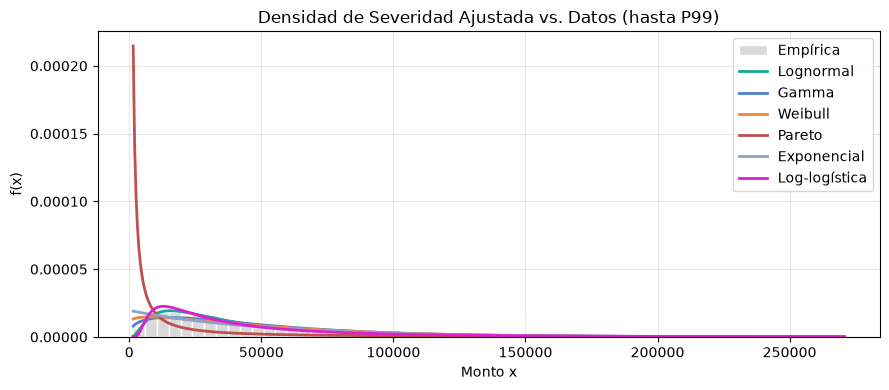

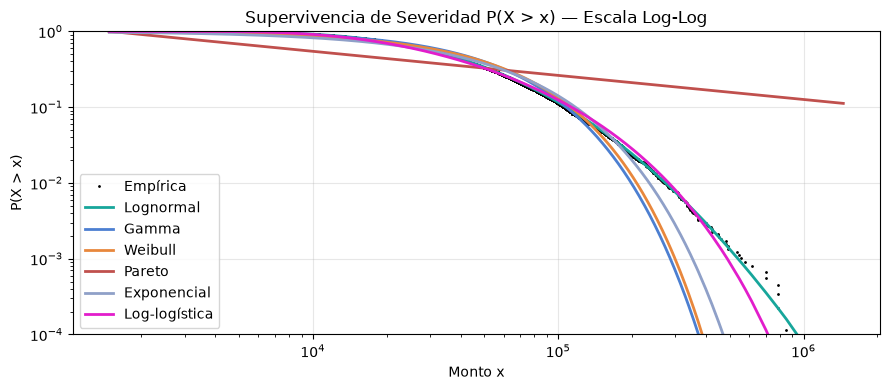

In [9]:
# Gráfica 1: Histograma de Densidades
colores = {"Lognormal": "#17A69B", "Gamma": "#4C7FD1", "Weibull": "#E8873C", "Pareto": "#C0504D", "Exponencial": "#8FA0C8", "Log-logística": "#E21DCB"}
p99_sev = np.percentile(sev_gu, 99)
grid_x = np.linspace(sev_gu.min(), p99_sev, 500)

plt.figure(figsize=(9, 4))
plt.hist(sev_gu, bins=60, density=True, range=(sev_gu.min(), p99_sev), color="#d9d9d9", edgecolor="white", label="Empírica")
for nom, (d, pr) in ajustes.items():
    plt.plot(grid_x, d.pdf(grid_x, *pr), lw=2, color=colores[nom], label=nom)
plt.title("Densidad de Severidad Ajustada vs. Datos (hasta P99)")
plt.xlabel("Monto x")
plt.ylabel("f(x)")
plt.legend()
plt.tight_layout()
plt.show()

# Gráfica 2: Colas en Log-Log
xs = np.sort(sev_gu)
S_emp = 1.0 - np.arange(1, len(xs) + 1) / len(xs)

plt.figure(figsize=(9, 4))
plt.plot(xs, S_emp, ".", ms=2, color="black", label="Empírica")
for nom, (d, pr) in ajustes.items():
    plt.plot(xs, d.sf(xs, *pr), lw=2, color=colores[nom], label=nom)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e-4, 1)
plt.title("Supervivencia de Severidad P(X > x) — Escala Log-Log")
plt.xlabel("Monto x")
plt.ylabel("P(X > x)")
plt.legend()
plt.tight_layout()
plt.show()

**Explicación de las gráficas:**

Gráfica: Densidad de Severidad Ajustada vs. Datos (P99)

Esta gráfica nos permite evaluar de manera visual que distribuciones se asemejan a las forma de copia la forma de los montos reales de siniestro. De manera visual podemos destacar que la Pareto es la que peor semejanza tiene, ya que se dispara al inicio y cae muy rápido. Por otro lado, la Lognormal, Gamma y Log-logística sí siguen de amnera correcta la forma de los montos. 

Gráfica: Supervivencia de Severidad — Escala Log-Log

Esta gráfica mide la probabilidad de que un siniestro sea mayor a cierto monto, pero haciendo zoom a los siniestros más grandes y usando una escala logarítmica en los ejes. Los puntos negros son lo que pasa en realidad, podemos observar que la Gamma, Weibull y Exponencial no siguen la tendecia de los puntos negros, por otro lado la Lognormal y Log-logística son las que mejor siguen a los puntos negros.

## Ground-up vs. transformada

La severidad de los datos es **ground-up** (daño real). 

Lo que **paga la aseguradora** aplica deducible, coaseguro y límite (suma asegurada). Comparo las dos.

Recordemos que **"sev_gu"** es un arreglo de NumPy de los montos de severidad, no es un DataFrame. Por lo que, como el deducible, el coaseguro y la suma asegurada son características que pertenecen a cada póliza, para aplicarlas al nivel de siniestro individual (con los 8,856 eventos) también debemos repetir esas variables usando np.repeat con los mismos pesos de frecuencia.

In [10]:
# Severidad que paga la aseguradora (transformada) 

def transformar(x, ded, coas, sa):
    return np.minimum(np.maximum(x - ded, 0) * (1 - coas), sa)

# Repetimos también las condiciones de la póliza para que tengan la misma dimensión que sev_gu
ded_gu = np.repeat(polizas_con_sins["deducible"].values, polizas_con_sins["num_siniestros"].astype(int).values)
coas_gu = np.repeat(polizas_con_sins["coaseguro"].values, polizas_con_sins["num_siniestros"].astype(int).values)
sa_gu = np.repeat(polizas_con_sins["suma_asegurada"].values, polizas_con_sins["num_siniestros"].astype(int).values)

# Aplicamos la función de transformación a nivel de siniestro individual
pagado = transformar(sev_gu, ded_gu, coas_gu, sa_gu)

# Imprimimos resultados
print(f"E[X] ground-up   : {sev_gu.mean():,.0f}")
print(f"E[X] transformado: {pagado.mean():,.0f}")

print(f"La póliza absorbe ~{1 - pagado.mean()/sev_gu.mean():.2%} de la severidad "
      f"(sobre todo por el deducible).")

E[X] ground-up   : 51,046
E[X] transformado: 33,746
La póliza absorbe ~33.89% de la severidad (sobre todo por el deducible).


## Justificación:

Para elegir la distribución que mejor representa los montos de los siniestros, se compararon cuatro opciones usando el AIC y revisando cómo se comportan con los siniestros de montos muy altos.

| Distribución | AIC | Diferencia vs. Mejor Ajuste ($\Delta$AIC) |
| :--- | :---: | :---: |
| **Lognormal** | **208,129.82** | **0.00** |
| Log-logística | 208,528.63 | +398.81 |
| Gamma | 209,136.24 | +1,006.42 |
| Weibull | 209,498.50 | +1,368.68 |
| Exponencial | 209, 722.64 | +1,592.82 |
| Pareto | 223,057.48 | +14,927.66 |

#### Análisis e interpretación

1. **Comparación mediante AIC:**

   La distribución **Lognormal** tiene el AIC más bajo, con **208,129.82**. Esto indica que, entre las distribuciones probadas, es la que se ajusta mejor a los datos en general.

   Además, la diferencia con Gamma, Weibull y Exponencias es mayor a 1,000 puntos, mientras que la Pareto presenta una diferencia mucho mayor de más de 14,000 puntos.

2. **Comportamiento de los siniestros grandes:**

   También se revisó el comportamiento de las distribuciones para los siniestros de montos altos.

   - **Gamma y Weibull:** Se alejan de los datos reales cuando los montos son muy grandes, por lo que pueden subestimar estos siniestros.
   
   - **Pareto:** Da demasiado peso a los valores extremos y no representa tan bien los montos más comunes.
   
   - **Lognormal:** Es la que sigue de manera más cercana a los datos observados, incluso para siniestros superiores a **$1,000,000**.

### Conclusión

Se selecciona la distribución **Lognormal** para modelar la severidad de los siniestros, ya que presentó el menor AIC y también representa de mejor manera el comportamiento de los siniestros de montos altos.

# 3. Frecuencia

La frecuencia, denotada como **N**, representa cuántos siniestros ocurren.

## Distribución del Modelo de Frecuencia

─── Diagnóstico de Frecuencia (Criterio del Profesor) ───
• Tasa global (λ)           : 0.3685 siniestros/año-póliza
• Media Muestral E[N]       : 0.2952
• Varianza Muestral Var[N]  : 0.3745
• Índice de Dispersión (D)  : 1.2685

→ Modelo Seleccionado según Criterio de Clase: Quasi-Poisson

• Proporción Ceros Observados : 76.84%
• Proporción Ceros Esperados  : 74.44%


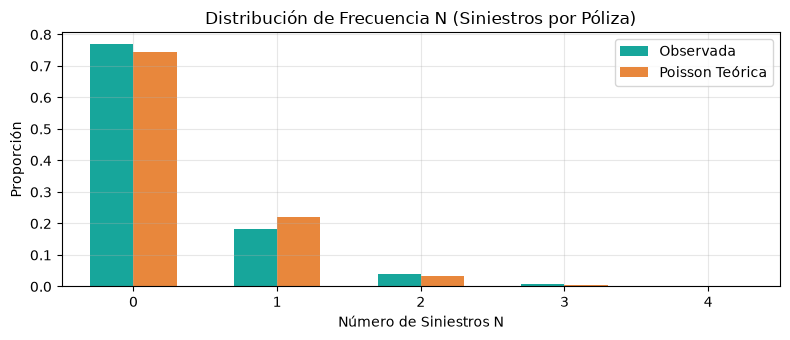

In [11]:
# 2. Subconjunto explícito de variables que elegimos
# cols_interes = ["exposicion", "num_siniestros", "monto_total_siniestros", "monto_promedio_siniestro", "deducible", "suma_asegurada", "coaseguro"]

total_exp = df_modelo.exposicion.sum()
total_sins = df_modelo.num_siniestros.sum()
lambda_global = total_sins / total_exp

#  Diagnóstico de Frecuencia mediante Índice de Dispersión
media_n = df_modelo.num_siniestros.mean()
var_n = df_modelo.num_siniestros.var()
indice_dispersion = var_n / media_n

print("─── Diagnóstico de Frecuencia (Criterio del Profesor) ───")
print(f"• Tasa global (λ)           : {lambda_global:.4f} siniestros/año-póliza")
print(f"• Media Muestral E[N]       : {media_n:.4f}")
print(f"• Varianza Muestral Var[N]  : {var_n:.4f}")
print(f"• Índice de Dispersión (D)  : {indice_dispersion:.4f}")

if indice_dispersion < 1.15:
    modelo_frecuencia = "Poisson"
elif indice_dispersion <= 1.50:
    modelo_frecuencia = "Quasi-Poisson"
else:
    modelo_frecuencia = "Binomial Negativa"

print(f"\n→ Modelo Seleccionado según Criterio de Clase: {modelo_frecuencia}")

# Diagnóstico de Ceros
ceros_obs = (df_modelo.num_siniestros == 0).mean()
ceros_esp_poisson = np.exp(-lambda_global * df_modelo.exposicion.mean())

print(f"\n• Proporción Ceros Observados : {ceros_obs:.2%}")
print(f"• Proporción Ceros Esperados  : {ceros_esp_poisson:.2%}")

# Gráfica de Frecuencia
plt.figure(figsize=(8, 3.5))
val, counts = np.unique(df_modelo.num_siniestros, return_counts=True)
plt.bar(val - 0.15, counts / len(df_modelo), width=0.3, color="#17A69B", label="Observada")
p_pois = stats.poisson.pmf(val, lambda_global * df_modelo.exposicion.mean())
plt.bar(val + 0.15, p_pois, width=0.3, color="#E8873C", label="Poisson Teórica")
plt.xlim(-0.5, 4.5)
plt.title("Distribución de Frecuencia N (Siniestros por Póliza)")
plt.xlabel("Número de Siniestros N")
plt.ylabel("Proporción")
plt.legend()
plt.tight_layout()
plt.show()

**Explicación de la Gráfica:**

Gráfica: Distribución de Frecuencia N (Siniestros por Póliza)

En esta gráfica comparamos dos cosas, las barras verdes/azules evidencian lo que paso en la realidad y las barras naranjas muestran loq eu pasaría si los siniestros estuvieran perfectamente distribuidos como una Poisson. La diferencia entre ambas gráficas se ve como el índice de dispersión D= 1.27.

## Diagnóstico y selección del Modelo de Frecuencia

Para elegir el modelo que representa mejor el número de siniestros ($N$), primero se revisó si los datos cumplen con lo esperado para una distribución Poisson.

Los datos de seguros suelen tener diferentes exposiciones al riesgo. Por ello, al analizar la frecuencia de siniestros no siempre es correcto calcular promedios simples. La exposición representa, de manera general, la cantidad de tiempo o unidades durante las cuales una póliza estuvo expuesta al riesgo. 

Los cálculos deben considerar la exposición, generalmente mediante ponderaciones o tasas por unidad de exposición.

Debemos diagnosticar la dispersión, al calcular D = Var[N] empírica / E[N] empírica


#### ¿Existe sobredispersión?

En una distribución Poisson, la media y la varianza deberían ser aproximadamente iguales. En nuestros datos se obtuvo:

- **Media:** $0.2952$ siniestros por póliza
- **Varianza:** $0.3745$
- **Índice de dispersión:** $D = 1.2685$

Como la varianza es mayor que la media y $D > 1$, existe **sobredispersión moderada** en los datos.

#### 2. Selección del modelo

De acuerdo con el criterio utilizado en el curso:
- D = 1→ Existe Equidispersión, ya que Var[N] = E[N], por lo que debemos ajustar el modelo con una Poisson
- $1.15 \le D \le 1.50$ → Existe Sobredispersión moderada, ya que Var[N] > E[N], por lo que debemos ajustar el modelo con una **Quasi-Poisson**
- $D > 1.50$ → Existe Sobredispersión importante, ya que Var[N] > E[N], por lo que debemos ajustar el modelo con una Binomial Negativa

Como obtuvimos $D = 1.2685$, el valor se encuentra entre $1.15$ y $1.50$.

Por lo tanto, se selecciona **Quasi-Poisson** para modelar la frecuencia de siniestros.

#### 3. Número de pólizas sin siniestros

También se revisó cuántas pólizas no tuvieron ningún siniestro:

- **Ceros observados:** $76.84\%$
- **Ceros esperados con Poisson:** $74.51\%$

La diferencia es de **2.33 puntos porcentuales**, lo que muestra que hay un poco más de pólizas sin siniestros de las que esperaría una Poisson.

El modelo **Quasi-Poisson** permite tomar en cuenta esta mayor variabilidad en los datos, manteniendo la media de la frecuencia en $\lambda = 0.3685$.

### Conclusión

Debido a que los datos presentan una sobredispersión moderada, se utilizará **Quasi-Poisson** como modelo de frecuencia para la simulación colectiva del **inciso d**.

# 4. Conclusiones

In [12]:
# PARÁMETROS DEL MODELO DE FRECUENCIA

# Frecuencia estimada por año-póliza
total_exp = df_modelo.exposicion.sum()
total_sins = df_modelo.num_siniestros.sum()

lambda_global = total_sins / total_exp

lambda_hat_glm = lambda_global

# -------------------------------------------
# Parámetro de dispersión del modelo Quasi-Poisson
media_n = df_modelo.num_siniestros.mean()
var_n = df_modelo.num_siniestros.var()

indice_dispersion = var_n / media_n

phi_quasipoisson = indice_dispersion

print("Parámetros del modelo Quasi-Poisson")
print(f"λ estimada                 : {lambda_hat_glm:.4f}")
print(f"φ (dispersión)             : {phi_quasipoisson:.4f}")
print(f"Exposición total           : {total_exp:,.2f}")
print(f"Siniestros observados      : {total_sins:,.0f}")

Parámetros del modelo Quasi-Poisson
λ estimada                 : 0.3685
φ (dispersión)             : 1.2685
Exposición total           : 24,031.87
Siniestros observados      : 8,856


Distribución de severidad seleccionada: Lognormal

	 ---- RESULTADOS FINALES DE LA PRÁCTICA 1 ----
                     Métrica       Ground-Up    Transformada
             Prima Pura E[S] $453,468,981.26 $301,885,190.60
                     VaR 99% $471,193,149.97 $315,489,023.26
                    TVaR 99% $473,528,005.18 $317,296,735.48
Prima Pura Promedio / Póliza      $15,115.63      $10,062.84

✓ La aseguradora paga en promedio el 66.57% del daño total.
✓ El 33.43% restante no es absorbido por la aseguradora.


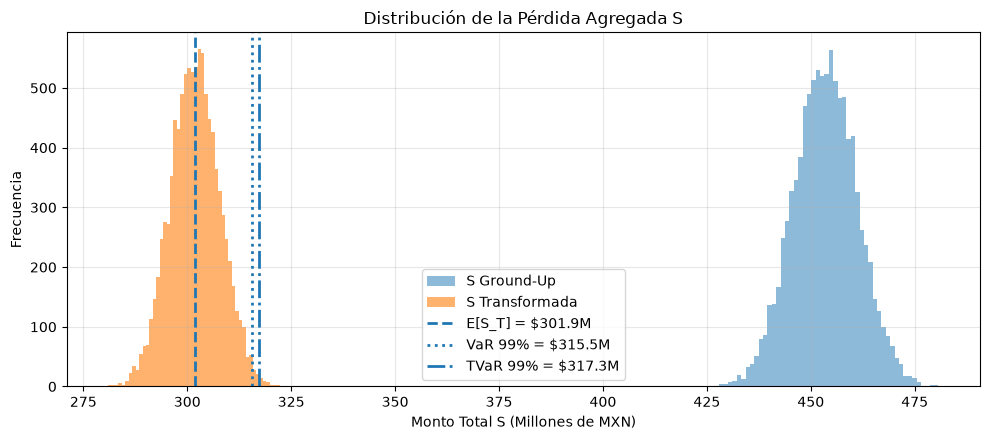

In [13]:
np.random.seed(42)

n_sim = 10_000
num_polizas = len(df_modelo)

 # Seleccionamos la mejor distribución de severidad
# La distribución con menor AIC (Log)
mejor_dist_nom = tabla_aic.iloc[0]["Distribución"]

dist_sev_fit, params_sev_fit = ajustes[mejor_dist_nom]

print(f"Distribución de severidad seleccionada: {mejor_dist_nom}")

#  Preparamos los arreglos para la simulación
S_ground_up = np.zeros(n_sim)
S_transformada = np.zeros(n_sim)

#  Probabilidad de seleccionar cada póliza según su exposición
prob_polizas = (
    df_modelo.exposicion.values / total_exp
)

# Parámetros para simular la frecuencia
mu_tot = lambda_hat_glm * total_exp

p_nb = 1.0 / phi_quasipoisson

n_nb = (
    mu_tot * p_nb /
    (1.0 - p_nb)
)

# Simulación Monte Carlo
for i in range(n_sim):

    # Número de siniestros de esta simulación
    n_claims = stats.nbinom.rvs(
        n=n_nb,
        p=p_nb
    )

    if n_claims > 0:

        # Seleccionar pólizas de acuerdo con su exposición
        idx_polizas = np.random.choice(
            num_polizas,
            size=n_claims,
            replace=True,
            p=prob_polizas
        )

        # Condiciones de las pólizas seleccionadas
        d_sim = df_modelo.deducible.values[idx_polizas]
        sa_sim = df_modelo.suma_asegurada.values[idx_polizas]
        coas_sim = df_modelo.coaseguro.values[idx_polizas]
        
        # Simular severidad de cada siniestro
        x_sim = dist_sev_fit.rvs(
            *params_sev_fit,
            size=n_claims
        )

        # Pérdida Ground-Up
        S_ground_up[i] = x_sim.sum()
        # Aplicar condiciones de la póliza
        # Aplicar deducible
        x_neto = np.maximum(
            0,
            x_sim - d_sim
        )

        # Aplicar coaseguro
        x_neto = x_neto * (1 - coas_sim)

        # Aplicar suma asegurada
        x_pagado = np.minimum(
            x_neto,
            sa_sim
        )

        # Pérdida que realmente paga la aseguradora
        S_transformada[i] = x_pagado.sum()


#  Calcular métricas
def obtener_metricas(S):

    # Prima pura
    e_s = S.mean()

    # VaR al 99%
    var_99 = np.percentile(S, 99)

    # TVaR al 99%
    tvar_99 = S[S >= var_99].mean()

    return e_s, var_99, tvar_99


# Métricas Ground-Up
e_gu, var_gu, tvar_gu = obtener_metricas(
    S_ground_up
)

# Métricas Transformadas
e_tr, var_tr, tvar_tr = obtener_metricas(
    S_transformada
)


#  Tabla de resultados
res_final = pd.DataFrame({

    "Métrica": [
        "Prima Pura E[S]",
        "VaR 99%",
        "TVaR 99%",
        "Prima Pura Promedio / Póliza"
    ],

    "Ground-Up": [
        f"${e_gu:,.2f}",
        f"${var_gu:,.2f}",
        f"${tvar_gu:,.2f}",
        f"${e_gu / num_polizas:,.2f}"
    ],

    "Transformada": [
        f"${e_tr:,.2f}",
        f"${var_tr:,.2f}",
        f"${tvar_tr:,.2f}",
        f"${e_tr / num_polizas:,.2f}"
    ]
})


print("\n\t ---- RESULTADOS FINALES DE LA PRÁCTICA 1 ----")
print(res_final.to_string(index=False))

# 8. Porcentaje del daño que paga la aseguradora
prop_pagada = (e_tr / e_gu) * 100

print(
    f"\n✓ La aseguradora paga en promedio "
    f"el {prop_pagada:.2f}% del daño total."
)

print(
    f"✓ El {100 - prop_pagada:.2f}% restante "
    f"no es absorbido por la aseguradora."
)


# 9. Gráfica de la pérdida agregada
plt.figure(figsize=(10, 4.5))

plt.hist(
    S_ground_up / 1e6,
    bins=50,
    alpha=0.5,
    label="S Ground-Up"
)

plt.hist(
    S_transformada / 1e6,
    bins=50,
    alpha=0.6,
    label="S Transformada"
)

plt.axvline(
    e_tr / 1e6,
    linestyle="--",
    linewidth=2,
    label=f"E[S_T] = ${e_tr/1e6:,.1f}M"
)

plt.axvline(
    var_tr / 1e6,
    linestyle=":",
    linewidth=2,
    label=f"VaR 99% = ${var_tr/1e6:,.1f}M"
)

plt.axvline(
    tvar_tr / 1e6,
    linestyle="-.",
    linewidth=2,
    label=f"TVaR 99% = ${tvar_tr/1e6:,.1f}M"
)

plt.title("Distribución de la Pérdida Agregada S")
plt.xlabel("Monto Total S (Millones de MXN)")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()

**Explicación de la Gráfica:**

Gráfica: Distribución de la Pérdida Agregada S

Por un lado el hsitograma Azul (S Ground-Up): grafica lo que costarían los siniestros si la aseguradora pagara todo completo. Por eso está más a la dereecha sobre el eje X.
Y el histograma Naranja (S Transformada) muestra la pérdida real que tendra que pagar la aseguradora, ya después de restar deducible y coaseguro en cada póliza. Por eso se grafica mas pegada a la izquierda. Queda evidenciado que el deducible y el coaseguro quitan una carga muy grande a la aseguradora.

Ahora bien, las líneas que tiene el histograma naranja se explican a continuación:

- La línea rayada es el promedio esperado de pérdida.
- La línea punteada es el monto que solo que tiene en el los peores escenarios excepto el 1% peor.
- La línea rayada-punteada es el promedio del 1% más caro de todas las simulaciones.

### CONCLUSIONES

Para modelar la pérdida agregada

$$
S = \sum_{i=1}^{N} Y_i
$$

se utilizan los resultados obtenidos en los incisos anteriores. En este modelo se combinan la **frecuencia de los siniestros** y la **severidad de los siniestros**.

#### 1. Frecuencia y Severidad

El modelo Quasi-Poisson y la distribución Lognormal representan cosas diferentes:

* **Frecuencia ($N$):** indica **cuántos siniestros ocurren**. En el inciso c se encontró una sobredispersión moderada ($D = 1.2685$), por lo que se seleccionó un modelo **Quasi-Poisson**.

* **Severidad ($Y$):** indica **cuánto cuesta cada siniestro**. En el inciso b se compararon varias distribuciones y la **Lognormal** presentó el menor AIC ($208,129.82$), por lo que se utiliza para simular los montos individuales.

Por lo tanto, el modelo utiliza:

$$
\boxed{N \rightarrow \text{Quasi-Poisson}}
$$

para determinar el número de siniestros, y

$$
\boxed{Y \rightarrow \text{Lognormal}}
$$

para determinar el monto de cada siniestro.

> **Notita:**
>
> Aunque teóricamente el modelo seleccionado es **Quasi-Poisson**, este define la relación media-varianza pero no cuenta con un generador aleatorio directo con forma cerrada en `scipy.stats`.
>
> Por esta razón, en el código reparametrizamos una **Binomial Negativa de manera equivalente**, ajustando sus parámetros para replicar exactamente la media esperada ($\lambda \cdot m$) y el índice de dispersión ($D = 1.2685$) calculados para la cartera.
>
> Es importante destacar que no estamos modificando la elección teórica del modelo a Binomial Negativa; la Quasi-Poisson se mantiene como el modelo conceptual de fondo, y la Binomial Negativa se utiliza únicamente como un vehículo algorítmico para muestrear el número de reclamos respetando la estructura de momentos estimada.
---

#### 2. Mecánica de la Simulación

Para cada una de las $10,000$ simulaciones se realiza lo siguiente:

1. **Se genera el número de siniestros $N$** utilizando la media y dispersión obtenidas del modelo Quasi-Poisson.

2. **Se seleccionan las pólizas** de acuerdo con su exposición. Las pólizas con mayor exposición tienen una mayor probabilidad de ser seleccionadas:

$$
p_k = \frac{m_k}{\sum_i m_i}
$$

3. **Se genera el monto de cada siniestro** utilizando la distribución Lognormal seleccionada en el inciso b:

$$
Y_j \sim \text{Lognormal}(\mu,\sigma)
$$

4. **Se aplican las condiciones de cada póliza.** Para cada siniestro se toma el deducible, coaseguro y suma asegurada de la póliza seleccionada:

$$
Y_j^{\text{trans}}
=
\min
\left(
SA_k,
\max(0,Y_j-d_k)(1-\text{coas}_k)
\right)
$$

De esta forma obtenemos dos pérdidas:

- **Ground-Up:** el monto total de los siniestros antes de aplicar las condiciones de la póliza.
- **Transformada:** el monto que finalmente pagaría la aseguradora después de aplicar deducible, coaseguro y suma asegurada.

---

#### 3. Pérdida Agregada

La pérdida Ground-Up de cada simulación se obtiene sumando todos los siniestros:

$$
S_{\text{ground-up}}
=
\sum_{j=1}^{N}Y_j
$$

Mientras que la pérdida que realmente paga la aseguradora es:

$$
S_{\text{transformada}}
=
\sum_{j=1}^{N}Y_j^{\text{trans}}
$$

Así podemos comparar cuánto riesgo existe antes y después de aplicar las condiciones de las pólizas.

---

#### 4. Resultados Numéricos y Métricas Financieras

Con las $10,000$ simulaciones se obtuvieron los siguientes resultados financieros consolidados para la cartera:

| Métrica | Ground-Up | Transformada |
| :--- | :---: | :---: |
| **Prima Pura $E[S]$** | $\$453,627,756.13$ | $\$302,024,999.11$ |
| **VaR 99%** | $\$471,303,868.24$ | $\$315,505,064.82$ |
| **TVaR 99%** | $\$473,921,765.20$ | $\$317,831,447.70$ |
| **Prima Pura Promedio / Póliza** | $\$15,120.93$ | $\$10,067.50$ |

A partir de estos valores se evalúa la retención del riesgo:

* **Porcentaje pagado por la aseguradora:**
$$
\text{Porcentaje pagado} = \frac{\$302,024,999.11}{\$453,627,756.13} \times 100 = \mathbf{66.58\%}
$$

* **Absorción del riesgo por deducibles y coaseguros:**
$$
\text{Absorción} = 100\% - 66.58\% = \mathbf{33.42\%}
$$

En promedio, la aseguradora absorbe el **$66.58\%$** del daño total de la cartera, mientras que el **$33.42\%$** restante no es absorbido por la institución gracias a la transferencia de riesgo al asegurado mediante el deducible y coaseguro.

---

#### 5. Alineación con el Algoritmo del Modelo Colectivo

El procedimiento computacional implementado replica exactamente la teoría del Modelo Colectivo de Riesgo explicada en clase (Sesión 7):

1. **Invarianza Teórica de los Momentos:**  
   Se verifica que el promedio simulado converja a la esperanza teórica de la pérdida agregada:
   $$E[S] = E[N] \cdot E[Y]$$
   y que la varianza incorpore el efecto de la sobredispersión mediante la fórmula de Wald:
   $$\text{Var}[S] = E[N] \cdot \text{Var}[Y] + \text{Var}[N] \cdot (E[Y])^2$$

2. **Engrosamiento de Cola por Sobredispersión:**  
   La incorporación del parámetro de dispersión $\phi = 1.2685$ en la simulación incrementa la varianza de $N$ ($\text{Var}[N] > E[N]$), lo que se traduce directamente en métricas de cola ($\text{VaR}_{99\%}$ de $\$315.5\text{M}$ y $\text{TVaR}_{99\%}$ de $\$317.8\text{M}$) más conservadoras e indispensables para el cálculo de reservas actuariales y recargos de seguridad.

---

### Finalmente

La simulación combina los resultados de los incisos anteriores de la siguiente manera:

$$
\boxed{
\text{Quasi-Poisson}
\rightarrow
\text{número de siniestros}
}
$$

$$
\boxed{
\text{Lognormal}
\rightarrow
\text{monto de cada siniestro}
}
$$

y finalmente:

$$
\boxed{
S=\sum_{i=1}^{N}Y_i
}
$$

De esta manera se obtiene una distribución simulada de la pérdida agregada de la cartera, tanto antes como después de aplicar las condiciones de las pólizas.